# HW04: Regional Data

Региональные данные: описательная статистика, дискретизация и ассоциативные правила.

In [1]:
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("data/sem13_data.xlsx")
raw_data = pd.read_excel(data_path)
raw_data.columns = [
    "region",
    "natural_growth",
    "unemployment",
    "salary",
    "temperature",
    "stadiums",
    "consumer_basket_cost",
    "housing_commissioned",
]
raw_data.head()

,region,natural_growth,unemployment,salary,temperature,stadiums,consumer_basket_cost,housing_commissioned
0,Белгородская область,-3649,3.6,54495.1,9.15,23,20570.5,853.2
1,Брянская область,-1588,2.6,48080.1,8.06,18,22168.7,609.6
2,Владимирская область,-3588,2.0,53285.6,6.38,28,23939.4,1027.5
3,Воронежская область,4392,3.2,53331.5,8.90,10,22689.1,1932.5
4,Ивановская область,-772,3.1,41928.8,5.84,14,22668.3,460.2


In [3]:
numeric_columns = [column for column in raw_data.columns if column != "region"]
data = raw_data.copy()
summary_table = data[numeric_columns].describe().T
summary_table

,count,mean,std,min,25%,50%,75%,max
natural_growth,82.0,2483.2805,11619.2061,-6051.00,-1734.7500,-466.00,1978.250,81305.0
unemployment,82.0,3.9659,3.3778,1.60,2.4250,3.10,3.775,27.9
salary,82.0,62660.9146,23482.2704,35824.60,48416.1750,54617.05,66883.375,159070.9
temperature,82.0,5.0939,5.1045,-10.55,3.1425,6.02,7.910,13.3
stadiums,82.0,19.7927,18.2146,0.00,8.0000,16.50,25.000,118.0
consumer_basket_cost,82.0,23492.0585,3365.2178,20342.10,21287.5000,22584.80,24391.200,37865.8
housing_commissioned,82.0,1314.2390,1707.7862,6.20,427.3250,743.75,1467.125,11404.5


In [4]:
correlation_matrix = data[numeric_columns].corr()
correlation_matrix

,natural_growth,unemployment,salary,temperature,stadiums,consumer_basket_cost,housing_commissioned
natural_growth,1.0000,-0.1459,0.2881,0.1474,0.6193,0.2787,0.8771
unemployment,-0.1459,1.0000,-0.2754,0.1327,-0.2288,-0.1764,-0.1530
salary,0.2881,-0.2754,1.0000,-0.6505,-0.0453,0.8904,0.1730
temperature,0.1474,0.1327,-0.6505,1.0000,0.1766,-0.5537,0.2224
stadiums,0.6193,-0.2288,-0.0453,0.1766,1.0000,-0.0647,0.7758
consumer_basket_cost,0.2787,-0.1764,0.8904,-0.5537,-0.0647,1.0000,0.1327
housing_commissioned,0.8771,-0.1530,0.1730,0.2224,0.7758,0.1327,1.0000


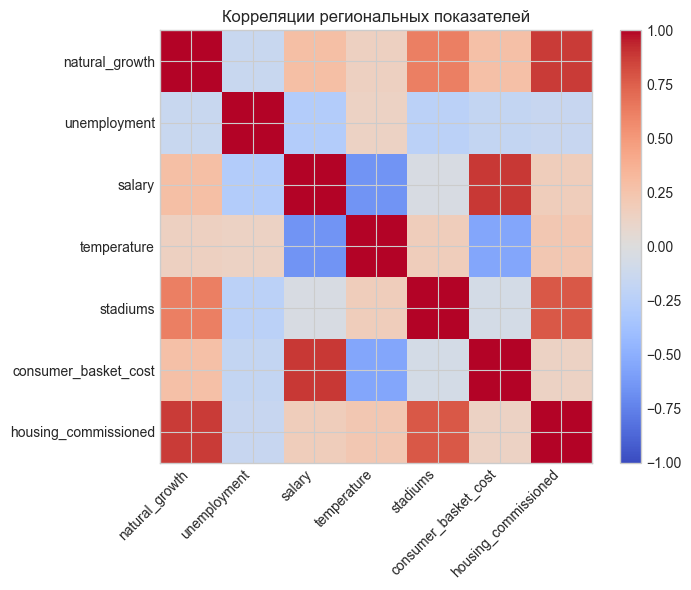

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=45, ha="right")
ax.set_yticklabels(numeric_columns)
ax.set_title("Корреляции региональных показателей")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

In [6]:
rank_table = pd.concat(
    [
        data.nlargest(10, "salary")[["region", "salary"]].assign(metric="highest_salary"),
        data.nsmallest(10, "unemployment")[["region", "unemployment"]].assign(metric="lowest_unemployment"),
        data.nlargest(10, "housing_commissioned")[["region", "housing_commissioned"]].assign(metric="highest_housing"),
    ],
    ignore_index=True,
)
rank_table

,region,salary,metric,unemployment,housing_commissioned
0,Чукотский автономный округ,159070.9,highest_salary,NaN,NaN
1,г. Москва,138881.8,highest_salary,NaN,NaN
2,Магаданская область,134645.8,highest_salary,NaN,NaN
3,Камчатский край,119562.5,highest_salary,NaN,NaN
4,Сахалинская область,114360.8,highest_salary,NaN,NaN
5,Республика Саха (Якутия),110230.3,highest_salary,NaN,NaN
6,Тюменская область,105981.2,highest_salary,NaN,NaN
7,Мурманская область,98818.0,highest_salary,NaN,NaN
8,г.Санкт-Петербург,96232.2,highest_salary,NaN,NaN
9,Московская область,83195.1,highest_salary,NaN,NaN


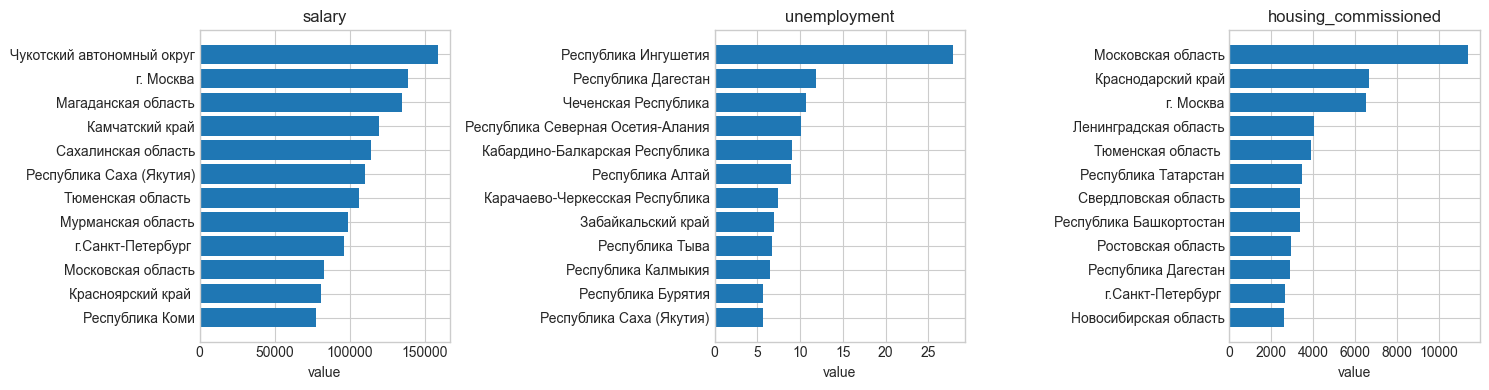

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ["salary", "unemployment", "housing_commissioned"]):
    ordered = data.sort_values(column, ascending=False).head(12)
    axis.barh(ordered["region"], ordered[column])
    axis.invert_yaxis()
    axis.set_title(column)
    axis.set_xlabel("value")
plt.tight_layout()

## Дискретизация

In [8]:
discretizer = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile", subsample=None)
discretized_values = discretizer.fit_transform(data[numeric_columns])
level_names = np.array(["low", "medium", "high"])

discretized_data = pd.DataFrame(discretized_values.astype(int), columns=numeric_columns)
items_data = pd.DataFrame(index=data.index)
for column in numeric_columns:
    items_data[column] = column + "=" + level_names[discretized_data[column].to_numpy()]

items_data.insert(0, "region", data["region"])
items_data.head()

,region,natural_growth,unemployment,salary,temperature,stadiums,consumer_basket_cost,housing_commissioned
0,Белгородская область,natural_growth=low,unemployment=high,salary=medium,temperature=high,stadiums=medium,consumer_basket_cost=low,housing_commissioned=medium
1,Брянская область,natural_growth=low,unemployment=low,salary=low,temperature=high,stadiums=medium,consumer_basket_cost=medium,housing_commissioned=medium
2,Владимирская область,natural_growth=low,unemployment=low,salary=medium,temperature=medium,stadiums=high,consumer_basket_cost=high,housing_commissioned=medium
3,Воронежская область,natural_growth=high,unemployment=medium,salary=medium,temperature=high,stadiums=medium,consumer_basket_cost=medium,housing_commissioned=high
4,Ивановская область,natural_growth=medium,unemployment=medium,salary=low,temperature=medium,stadiums=medium,consumer_basket_cost=medium,housing_commissioned=low


In [9]:
transactions = items_data[numeric_columns].apply(lambda row: set(row), axis=1).tolist()
all_items = sorted({item for transaction in transactions for item in transaction})

def calculate_support(itemset):
    itemset = set(itemset)
    return sum(itemset.issubset(transaction) for transaction in transactions) / len(transactions)

frequent_rows = []
for size in [1, 2, 3]:
    for itemset in combinations(all_items, size):
        support = calculate_support(itemset)
        if support >= 0.18:
            frequent_rows.append({"itemset": tuple(itemset), "support": support, "size": size})

frequent_itemsets = pd.DataFrame(frequent_rows).sort_values(["size", "support"], ascending=[True, False])
frequent_itemsets

,itemset,support,size
18,"(unemployment=high,)",0.3902,1
12,"(stadiums=high,)",0.3537,1
0,"(consumer_basket_cost=high,)",0.3415,1
3,"(housing_commissioned=high,)",0.3415,1
6,"(natural_growth=high,)",0.3415,1
9,"(salary=high,)",0.3415,1
15,"(temperature=high,)",0.3415,1
1,"(consumer_basket_cost=low,)",0.3293,1
2,"(consumer_basket_cost=medium,)",0.3293,1
4,"(housing_commissioned=low,)",0.3293,1


In [10]:
rule_rows = []
for itemset in frequent_itemsets.loc[frequent_itemsets["size"] >= 2, "itemset"]:
    itemset = set(itemset)
    for antecedent_size in range(1, len(itemset)):
        for antecedent in combinations(sorted(itemset), antecedent_size):
            antecedent = set(antecedent)
            consequent = itemset - antecedent
            support_itemset = calculate_support(itemset)
            support_antecedent = calculate_support(antecedent)
            support_consequent = calculate_support(consequent)
            confidence = support_itemset / support_antecedent
            lift = confidence / support_consequent
            if confidence >= 0.55 and lift >= 1.05:
                rule_rows.append(
                    {
                        "antecedent": tuple(sorted(antecedent)),
                        "consequent": tuple(sorted(consequent)),
                        "support": support_itemset,
                        "confidence": confidence,
                        "lift": lift,
                    }
                )

rules = pd.DataFrame(rule_rows).sort_values(["lift", "confidence", "support"], ascending=False)
rules.head(20)

,antecedent,consequent,support,confidence,lift
29,"(consumer_basket_cost=high, temperature=low)","(salary=high,)",0.1951,0.8421,2.4662
26,"(salary=high,)","(consumer_basket_cost=high, temperature=low)",0.1951,0.5714,2.4662
28,"(consumer_basket_cost=high, salary=high)","(temperature=low,)",0.1951,0.8000,2.4296
27,"(temperature=low,)","(consumer_basket_cost=high, salary=high)",0.1951,0.5926,2.4296
1,"(temperature=low,)","(salary=high,)",0.2683,0.8148,2.3862
0,"(salary=high,)","(temperature=low,)",0.2683,0.7857,2.3862
6,"(housing_commissioned=low,)","(stadiums=low,)",0.2439,0.7407,2.3362
7,"(stadiums=low,)","(housing_commissioned=low,)",0.2439,0.7692,2.3362
30,"(salary=high, temperature=low)","(consumer_basket_cost=high,)",0.1951,0.7273,2.1299
25,"(consumer_basket_cost=high,)","(salary=high, temperature=low)",0.1951,0.5714,2.1299


## Кластеры регионов

In [11]:
scaled_data = StandardScaler().fit_transform(data[numeric_columns])
cluster_rows = []
for cluster_count in range(2, 7):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=20)
    labels = model.fit_predict(scaled_data)
    cluster_rows.append(
        {
            "clusters": cluster_count,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(scaled_data, labels),
        }
    )

cluster_quality = pd.DataFrame(cluster_rows)
cluster_quality

,clusters,inertia,silhouette
0,2,420.0104,0.6542
1,3,301.9089,0.3677
2,4,249.2643,0.3709
3,5,202.8930,0.3092
4,6,173.4512,0.2898


In [12]:
best_cluster_count = int(cluster_quality.sort_values("silhouette", ascending=False).iloc[0]["clusters"])
cluster_model = KMeans(n_clusters=best_cluster_count, random_state=42, n_init=20)
data_with_clusters = data.copy()
data_with_clusters["cluster"] = cluster_model.fit_predict(scaled_data)
cluster_profile = data_with_clusters.groupby("cluster")[numeric_columns].mean()
cluster_sizes = data_with_clusters["cluster"].value_counts().sort_index().to_frame("regions")
cluster_profile.join(cluster_sizes)

,natural_growth,unemployment,salary,temperature,stadiums,consumer_basket_cost,housing_commissioned,regions
cluster,,,,,,,,
0,618.0000,4.0354,61491.9203,4.9435,17.6456,23293.4089,1052.3165,79
1,51602.3333,2.1333,93444.4333,9.0533,76.3333,28723.1667,8211.5333,3


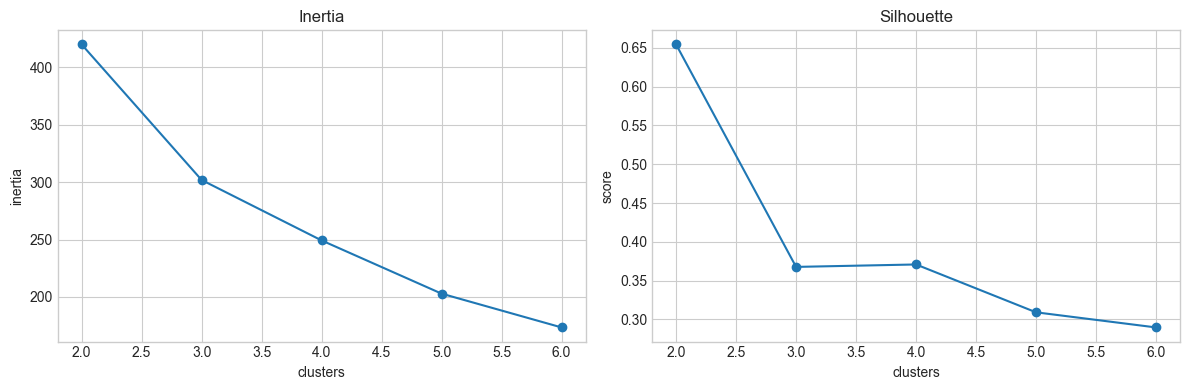

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cluster_quality["clusters"], cluster_quality["inertia"], marker="o")
axes[0].set_title("Inertia")
axes[0].set_xlabel("clusters")
axes[0].set_ylabel("inertia")

axes[1].plot(cluster_quality["clusters"], cluster_quality["silhouette"], marker="o")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("clusters")
axes[1].set_ylabel("score")
plt.tight_layout()

In [14]:
cluster_members = data_with_clusters.sort_values(["cluster", "region"])[["cluster", "region"]]
cluster_members

,cluster,region
64,0,Алтайский край
77,0,Амурская область
20,0,Архангельская область
32,0,Астраханская область
0,0,Белгородская область
...,...,...
35,0,г. Севастополь
27,0,г.Санкт-Петербург
31,1,Краснодарский край
9,1,Московская область


## Вывод

Региональные показатели удобно сравнивать через ранги, корреляции, дискретные профили и кластеры. Ассоциативные правила показывают устойчивые сочетания уровней показателей, а кластеризация собирает похожие регионы в группы.